# Part 1: Linear model

Pour la première deadline il faut rendre un fichier `y_pred.csv` qui sont les prédictions du modèle linéaire sur `X.csv` (dans *data/data_unlabeled/*)

1. Train/Validation Split
2. Baseline Model
3. Model Selection (tester plusieurs modèles)
4. Hyperparameter Tuning
5. Évaluation Finale sur Test Set
6. Prédictions sur Unlabeled Data

## Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, make_scorer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor

# Save and load models
import sys
sys.path.append('..')
import joblib
import os
import json

In [4]:
X_train = pd.read_csv('../data/data_labeled/X_train.csv')
y_train = pd.read_csv('../data/data_labeled/y_train.csv', header=None, names=['risk'])
X_test = pd.read_csv('../data/data_labeled/X_test.csv')
y_test = pd.read_csv('../data/data_labeled/y_test.csv', header=None, names=['risk'])
X_unlabeled = pd.read_csv('../data/data_unlabeled/X.csv')

## Preprocessing

### Preprocessing classique

In [5]:
drop_cols = ['img_filename'] # Variables à supprimer
num_cols = ['age', 'blood pressure', 'calcium', 'cholesterol', 'hemoglobin', 
            'height', 'potassium', 'vitamin D', 'weight'] # Var. numériques
nom_cols = ['profession'] # Variable catégorielle nominale (pas d'ordre logique)
ord_cols = ['sarsaparilla', 'smurfberry liquor', 'smurfin donuts'] # Variables catégorielles ordinales (ordre important : Very low -> Very high)
ord_categories = [
    ['Very low', 'Low', 'Moderate', 'High', 'Very high'], # sarsaparilla
    ['Very low', 'Low', 'Moderate', 'High', 'Very high'], # smurfberry liquor
    ['Very low', 'Low', 'Moderate', 'High', 'Very high']  # smurfin donuts
]

# Construction du Pipeline de preprocessing
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
ord_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ord_categories))
])
nom_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('ord', ord_transformer, ord_cols),
        ('nom', nom_transformer, nom_cols),
        ('drop', 'drop', drop_cols) # Supprime img_filename automatiquement
    ])

### Mutual information


Top features (|Corrélation| avec y_log):
  num__blood pressure : 0.654
  num__cholesterol    : 0.448
  num__weight         : 0.422
  ord__smurfin donuts : 0.320
  nom__profession_administration and governance: 0.235
  num__age            : 0.230
  ord__sarsaparilla   : 0.207

Top features (Mutual Information):
  num__blood pressure : 0.252
  num__cholesterol    : 0.103
  num__weight         : 0.093
  num__potassium      : 0.058
  ord__smurfin donuts : 0.047
  num__vitamin D      : 0.040
  num__age            : 0.040

Top features (Random Forest Importance):
  num__blood pressure : 0.556
  num__hemoglobin     : 0.110
  num__potassium      : 0.098
  num__age            : 0.042
  num__weight         : 0.041
  num__cholesterol    : 0.034
  num__height         : 0.025


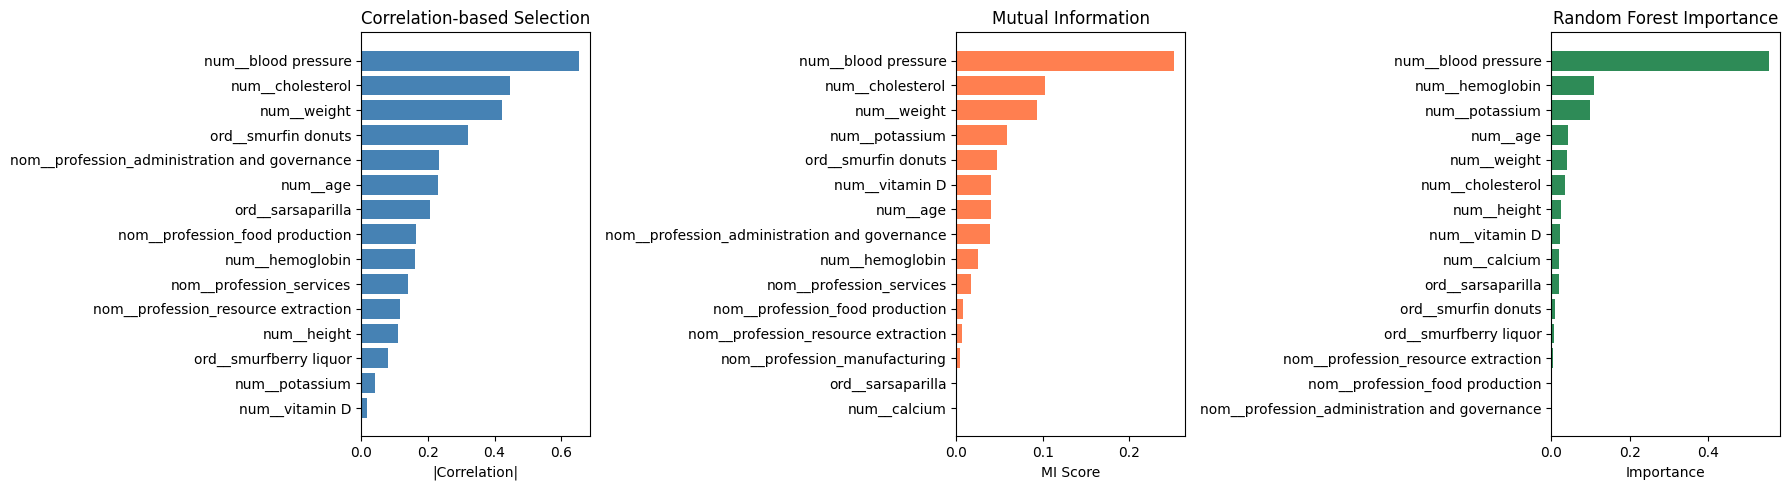


Features sélectionnées par consensus (11): ['num__hemoglobin', 'num__cholesterol', 'num__height', 'nom__profession_administration and governance', 'ord__sarsaparilla', 'ord__smurfin donuts', 'num__vitamin D', 'num__age', 'num__weight', 'num__blood pressure', 'num__potassium']


In [6]:
X_train_processed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

y_target_original = y_train['risk'].values.ravel()
y_target_log = np.log1p(y_target_original) 
y_target_sel = y_target_log.copy()
y_target_sel = y_target_log.copy() 

# ---------------------------------------------------
# 1. Correlation-based Feature Selection
# ---------------------------------------------------
correlations = []
for i, col in enumerate(feature_names):
    corr = np.corrcoef(X_train_processed[:, i], y_target_sel)[0, 1]
    correlations.append((col, abs(corr)))
    
correlations.sort(key=lambda x: x[1], reverse=True)

print("\nTop features (|Corrélation| avec y_log):")
for name, corr in correlations[:7]:
    print(f"  {name:20s}: {corr:.3f}")

# ---------------------------------------------------
# 2. Mutual Information
# ---------------------------------------------------
# Appliqué sur les données numériques (X_train_processed) et la cible (y_target_sel)
mi_scores = mutual_info_regression(X_train_processed, y_target_sel, random_state=42)
mi_ranking = sorted(zip(feature_names, mi_scores), key=lambda x: x[1], reverse=True)

print("\nTop features (Mutual Information):")
for name, score in mi_ranking[:7]:
    print(f"  {name:20s}: {score:.3f}")

# ---------------------------------------------------
# 3. Random Forest Feature Importance (sur données numériques)
# ---------------------------------------------------
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_selector.fit(X_train_processed, y_target_sel) 

importances = sorted(zip(feature_names, rf_selector.feature_importances_), 
                     key=lambda x: x[1], reverse=True)

print("\nTop features (Random Forest Importance):")
for name, imp in importances[:7]:
    print(f"  {name:20s}: {imp:.3f}")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Corrélation
corr_df = pd.DataFrame(correlations[:15], columns=['Feature', 'Score'])
axes[0].barh(corr_df['Feature'], corr_df['Score'], color='steelblue')
axes[0].set_xlabel('|Correlation|')
axes[0].set_title('Correlation-based Selection')
axes[0].invert_yaxis()

# Mutual Information
mi_df = pd.DataFrame(mi_ranking[:15], columns=['Feature', 'Score'])
axes[1].barh(mi_df['Feature'], mi_df['Score'], color='coral')
axes[1].set_xlabel('MI Score')
axes[1].set_title('Mutual Information')
axes[1].invert_yaxis()

# Random Forest
imp_df = pd.DataFrame(importances[:15], columns=['Feature', 'Score'])
axes[2].barh(imp_df['Feature'], imp_df['Score'], color='seagreen')
axes[2].set_xlabel('Importance')
axes[2].set_title('Random Forest Importance')
axes[2].invert_yaxis()
plt.tight_layout()
plt.savefig('../results/reports/figures/feature_selection_comparison_cb_mi_rf.pdf')
plt.show()

top_features = list(set([f[0] for f in correlations[:7]] + 
                       [f[0] for f in mi_ranking[:7]] + 
                       [f[0] for f in importances[:7]]))

print(f"\nFeatures sélectionnées par consensus ({len(top_features)}): {top_features}")

## Analyse unidmiensionnelle : distribution des variables numériques

Pourquoi ? Vérifier si les données suivent une distribution normale ou si elles sont fortement asymétriques (dans ce cas on devra appliquer une transformation logartihmique par exemple).

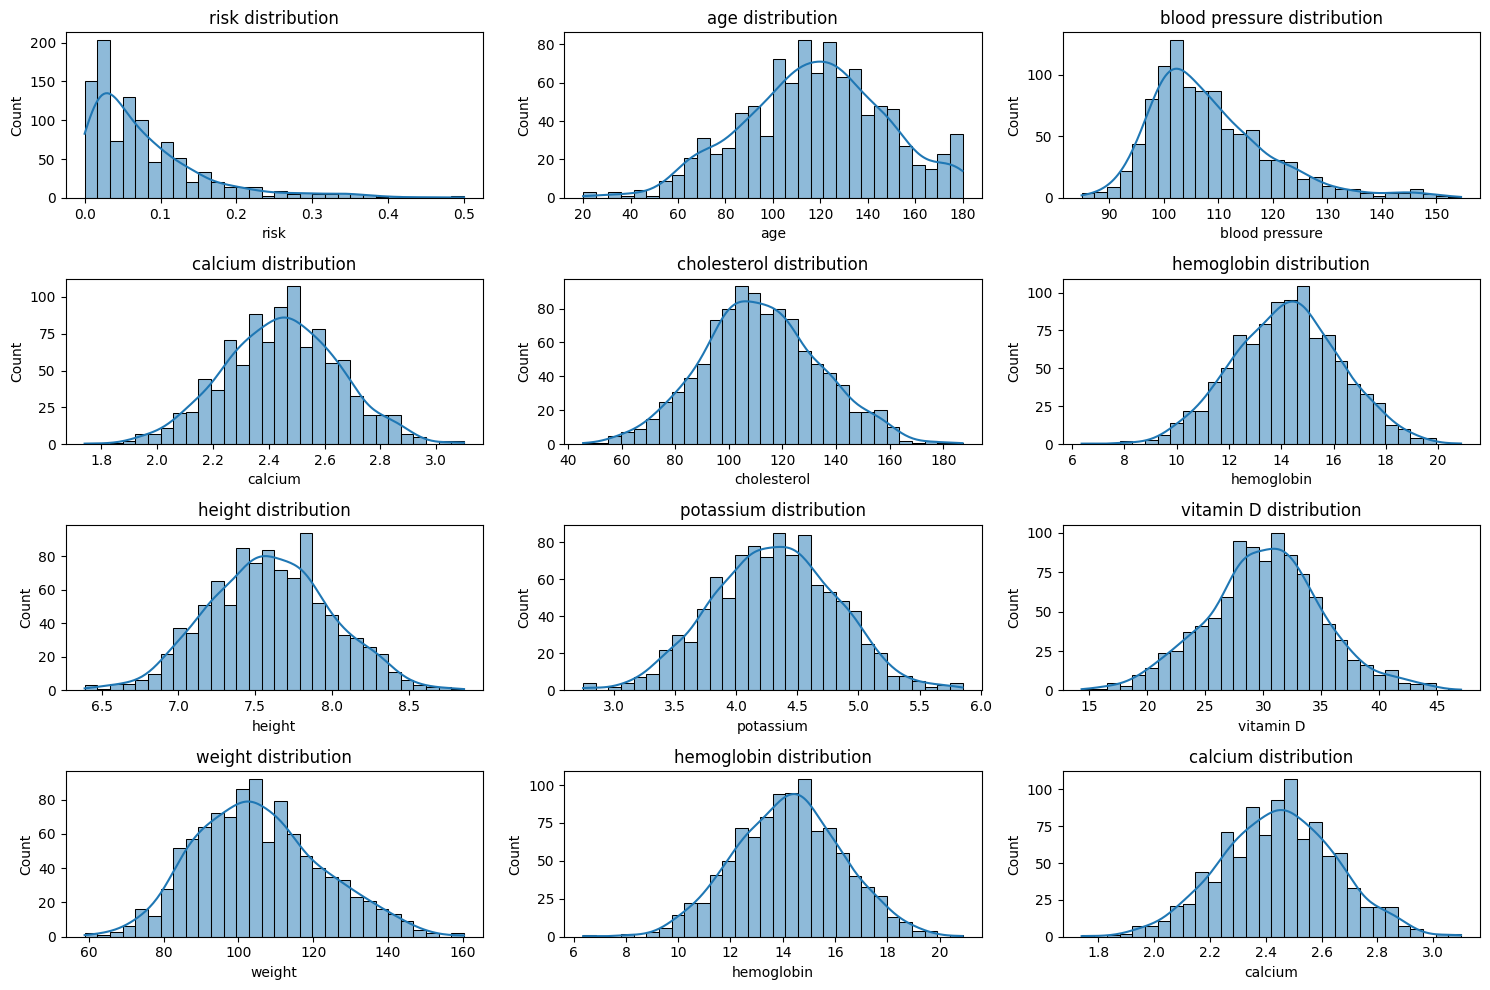

In [7]:
# Variables numériques à visualiser (celles listées comme influentes + la cible)
cols_to_plot = ['risk','age', 'blood pressure', 'calcium', 'cholesterol', 'hemoglobin', 
            'height', 'potassium', 'vitamin D', 'weight', 'hemoglobin', 'calcium']
data_for_viz = X_train.copy()
data_for_viz['risk'] = y_train['risk']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot):
    plt.subplot(4, 3, i + 1)
    sns.histplot(data_for_viz[col], kde=True, bins=30)
    plt.title(f'{col} distribution')
    plt.xlabel(col)
plt.tight_layout()
#plt.savefig('../results/reports/figures/features_distributions_selected_features.pdf')
plt.show()

**Remarque** : On remarque que la target est très asymétrique (skewed). Il faut rendre la cible plus symétrique en la transformant avec une fonction logarithmique.

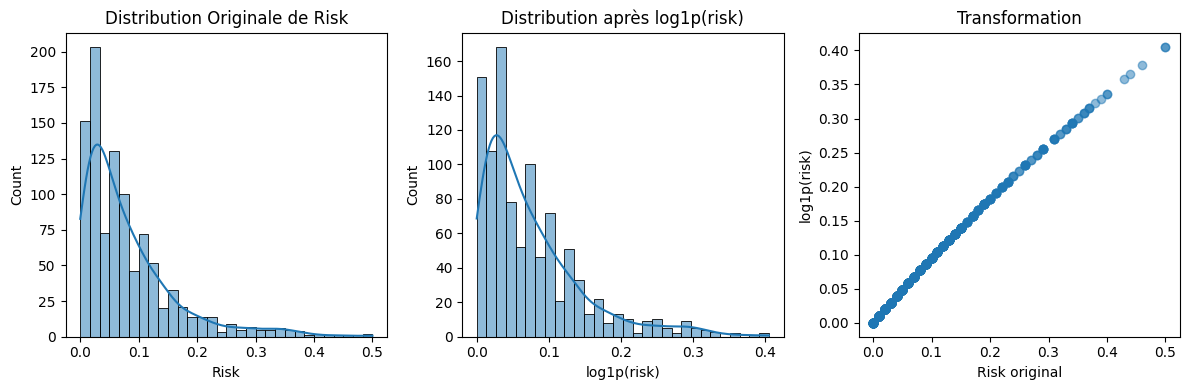

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(y_train['risk'], kde=True, bins=30)
plt.title('Distribution Originale de Risk')
plt.xlabel('Risk')
y_train_log = np.log1p(y_train['risk']) 

plt.subplot(1, 3, 2)
sns.histplot(y_train_log, kde=True, bins=30)
plt.title('Distribution après log1p(risk)')
plt.xlabel('log1p(risk)')

plt.subplot(1, 3, 3)
plt.scatter(y_train['risk'], y_train_log, alpha=0.5)
plt.xlabel('Risk original')
plt.ylabel('log1p(risk)')
plt.title('Transformation')
plt.tight_layout()
plt.show()

## Baseline model : sans log

In [9]:
model_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

# Cross-validation
scores_baseline = cross_val_score(
    model_baseline, X_train, y_train['risk'].values.ravel(),
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
print(f"RMSE CV (baseline): {-scores_baseline.mean():.4f} (+/- {scores_baseline.std():.4f})")

model_baseline.fit(X_train, y_train['risk'].values.ravel())
y_pred_baseline = model_baseline.predict(X_test)
rmse_baseline = root_mean_squared_error(y_test['risk'], y_pred_baseline)
print(f"RMSE Test (baseline): {rmse_baseline:.4f}")

RMSE CV (baseline): 0.0558 (+/- 0.0022)
RMSE Test (baseline): 0.0558


## Modele avec transformation log

In [10]:
y_target_log = np.log1p(y_train['risk'].values.ravel())
model_log = Pipeline(steps=[
     ('preprocessor', preprocessor),
     ('regressor', Ridge(alpha=1.0))
])
scores_log = cross_val_score(
     model_log, X_train, y_target_log,
     cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
 )
print(f"RMSE CV (log scale): {-scores_log.mean():.4f}")

model_log.fit(X_train, y_target_log)
y_pred_log_scale = model_log.predict(X_test)
y_pred_log_original = np.expm1(y_pred_log_scale)
y_pred_log_original = np.maximum(0, y_pred_log_original)
rmse_log = root_mean_squared_error(y_test['risk'], y_pred_log_original)
print(f"RMSE Test (avec log): {rmse_log:.4f}")

RMSE CV (log scale): 0.0485
RMSE Test (avec log): 0.0550


## Feature selection & Hyperparameter tuning

In [11]:
# Décider: avec ou sans log selon le meilleur résultat précédent
use_log = rmse_log < rmse_baseline

base_regressor = Ridge()

# Encapsuler le régresseur avec la transformation de la cible log(1+y)
# Si use_log est True, TTR appliquera np.log1p() avant le fit et np.expm1() après le predict.
# Si use_log est False, nous utiliserons le Pipeline standard (non-TTR).

if use_log:
    final_regressor = TransformedTargetRegressor(
        regressor=base_regressor,
        func=np.log1p,
        inverse_func=np.expm1
    )
    model_poly = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('poly', PolynomialFeatures(include_bias=False)),
        ('regressor', final_regressor) # Maintenant TTR
    ])
    # Les paramètres de Ridge doivent être accédés via 'regressor__regressor__alpha'
    param_grid = {
        'regressor__regressor__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0, 300.0, 500.0],
        'poly__degree': [2]
    }
    
else:
    model_poly = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('poly', PolynomialFeatures(include_bias=False)),
        ('regressor', base_regressor) # Simple Ridge
    ])
    param_grid = {
        'regressor__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0, 300.0, 500.0],
        'poly__degree': [2]
    }


grid_search = GridSearchCV(
    model_poly, param_grid, cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1, n_jobs=-1
)

# Nous utilisons TOUJOURS la cible NON TRANSFORMÉE pour le fit
y_target_original = y_train['risk'].values.ravel() 

grid_search.fit(X_train, y_target_original) 
best_model = grid_search.best_estimator_

print(f"\nMeilleurs paramètres: {grid_search.best_params_}")
print(f"Meilleur RMSE CV: {-grid_search.best_score_:.4f}")

# Les prédictions sont déjà sur l'échelle ORIGINALE si use_log est True, 
# grâce à inverse_func=np.expm1 du TransformedTargetRegressor.
y_pred_final = best_model.predict(X_test)
rmse_final = root_mean_squared_error(y_test['risk'], y_pred_final)
print(f"RMSE Test (modèle final): {rmse_final:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Meilleurs paramètres: {'poly__degree': 2, 'regressor__regressor__alpha': 200.0}
Meilleur RMSE CV: 0.0426
RMSE Test (modèle final): 0.0417


## Feature selection

Test de 1 à 18 features...
Features:  1/18 -> RMSE CV: 0.0562
Features:  2/18 -> RMSE CV: 0.0515
Features:  3/18 -> RMSE CV: 0.0470
Features:  4/18 -> RMSE CV: 0.0452
Features:  5/18 -> RMSE CV: 0.0436
Features:  6/18 -> RMSE CV: 0.0426
Features:  7/18 -> RMSE CV: 0.0419
Features:  8/18 -> RMSE CV: 0.0412
Features:  9/18 -> RMSE CV: 0.0412
Features: 10/18 -> RMSE CV: 0.0411
Features: 11/18 -> RMSE CV: 0.0411
Features: 12/18 -> RMSE CV: 0.0411
Features: 13/18 -> RMSE CV: 0.0411
Features: 14/18 -> RMSE CV: 0.0412
Features: 15/18 -> RMSE CV: 0.0413
Features: 16/18 -> RMSE CV: 0.0415
Features: 17/18 -> RMSE CV: 0.0422
Features: 18/18 -> Calcul du score pour toutes les features...


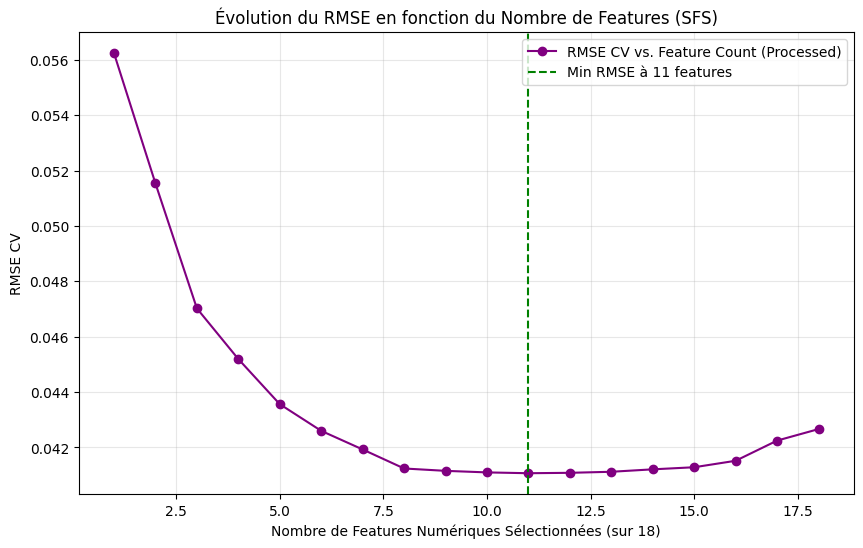


Analyse de la Courbe SFS:
Meilleur RMSE CV obtenu: 0.0411 avec 11 features traitées.
RMSE avec toutes les features: 0.0427


In [12]:
# Pre-process X_train une seule fois pour obtenir les features numériques
X_train_processed = preprocessor.fit_transform(X_train)
feature_names_processed = preprocessor.get_feature_names_out()
n_features_processed = X_train_processed.shape[1]
best_model_steps = best_model.steps # Il inclut PolynomialFeatures et le TransformedTargetRegressor/Ridge
# Le pipeline commence à partir de l'étape 1 (poly) car l'étape 0 (preprocessor) est déjà exécutée
core_pipeline = Pipeline(best_model_steps[1:])

# La cible NON transformée (y_target_original) est nécessaire pour le fit du TTR
y_target_original = y_train['risk'].values.ravel()

rmse_history_sfs = []
n_features_tested_sfs = []
max_k_sfs = n_features_processed - 1
print(f"Test de 1 à {n_features_processed} features...")

for k in range(1, max_k_sfs + 1):
    sfs = SFS(
        estimator=core_pipeline,
        n_features_to_select=k,
        direction='forward',
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    sfs.fit(X_train_processed, y_target_original)
    selected_indices = sfs.get_support(indices=True)
    X_subset = X_train_processed[:, selected_indices]
    cv_scores = cross_val_score(
        core_pipeline,
        X_subset,
        y_target_original,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    avg_rmse = -cv_scores.mean()

    n_features_tested_sfs.append(k)
    rmse_history_sfs.append(avg_rmse)

    print(f"Features: {k:2d}/{n_features_processed} -> RMSE CV: {avg_rmse:.4f}")

print(f"Features: {n_features_processed:2d}/{n_features_processed} -> Calcul du score pour toutes les features...")
final_cv_scores = cross_val_score(
    core_pipeline,
    X_train_processed, # Utilise toutes les features preprocessed
    y_target_original,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

final_avg_rmse = -final_cv_scores.mean()
n_features_tested_sfs.append(n_features_processed)
rmse_history_sfs.append(final_avg_rmse)


# --- Plotting des résultats ---
plt.figure(figsize=(10, 6))
plt.plot(n_features_tested_sfs, rmse_history_sfs, 'o-', label='RMSE CV vs. Feature Count (Processed)', color='purple')
min_rmse_index = np.argmin(rmse_history_sfs)
plt.axvline(x=n_features_tested_sfs[min_rmse_index], color='green', linestyle='--', label=f'Min RMSE à {n_features_tested_sfs[min_rmse_index]} features')
plt.xlabel(f"Nombre de Features Numériques Sélectionnées (sur {n_features_processed})")
plt.ylabel("RMSE CV")
plt.title("Évolution du RMSE en fonction du Nombre de Features (SFS)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nAnalyse de la Courbe SFS:")
print(f"Meilleur RMSE CV obtenu: {rmse_history_sfs[min_rmse_index]:.4f} avec {n_features_tested_sfs[min_rmse_index]} features traitées.")
print(f"RMSE avec toutes les features: {rmse_history_sfs[-1]:.4f}")

In [13]:
# Identifier le nombre optimal de features
best_k = n_features_tested_sfs[min_rmse_index]
rmse_final_sfs_cv = rmse_history_sfs[min_rmse_index]

print(f"\n--- Application de la Feature Selection SFS (k={best_k}) ---")
print(f"Meilleur RMSE CV (SFS): {rmse_final_sfs_cv:.4f}")

# Ré-exécuter le SFS uniquement pour la taille optimale pour obtenir les indices exacts
sfs_optimal = SFS(
    estimator=core_pipeline, # core_pipeline = (Poly + TTR/Ridge)
    n_features_to_select=best_k,
    direction='forward',
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit SFS sur toutes les données preprocessed pour obtenir les indices
# X_train_processed et y_target_original sont définis dans le bloc SFS précédent
sfs_optimal.fit(X_train_processed, y_target_original)

# Extraire les indices et le sous-ensemble de données optimal
best_indices = sfs_optimal.get_support(indices=True)
X_train_sfs = X_train_processed[:, best_indices]

# Entraîner le modèle final (Poly + TTR/Ridge) sur ce sous-ensemble
# On clone le pipeline pour s'assurer qu'il est ré-initialisé.
optimal_sfs_model = clone(core_pipeline)
optimal_sfs_model.fit(X_train_sfs, y_target_original)

X_test_processed = preprocessor.transform(X_test)
X_test_sfs = X_test_processed[:, best_indices]

y_pred_sfs = optimal_sfs_model.predict(X_test_sfs)

# Retour à l'échelle originale si log a été utilisé
rmse_sfs_test = root_mean_squared_error(y_test['risk'], y_pred_sfs)
best_model = optimal_sfs_model
final_best_indices = best_indices # Garder les indices pour les prédictions
rmse_final = rmse_sfs_test # C'est le nouveau RMSE ttest final

print(f"RMSE Test (Modèle SFS Optimisé - {best_k} features): {rmse_final:.4f}")


--- Application de la Feature Selection SFS (k=11) ---
Meilleur RMSE CV (SFS): 0.0411
RMSE Test (Modèle SFS Optimisé - 11 features): 0.0423


## Analyse graphique

### Learning curve
**Interet:** Montrer l'évolution du RMSE à la fois sur le training set et le validation set (CV) à mesure que la taille de l'ensemble d'entraînement augmente.

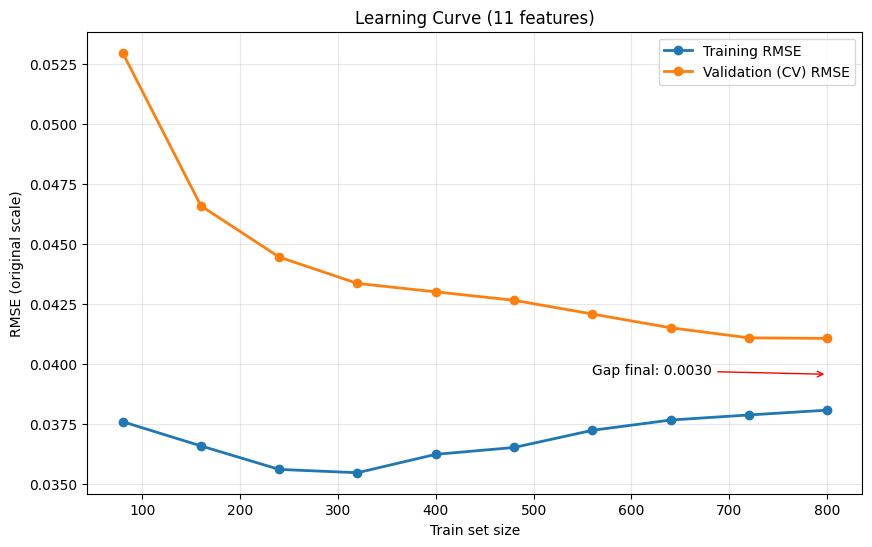

In [14]:
# Le pipeline 'best_model' (core_pipeline) ne contient pas le preprocessor
# Il faut donc lui fournir les données déjà transformées (X_train_sfs)
train_sizes_abs, train_scores, val_scores = learning_curve(
    best_model, X_train_sfs, y_target_original,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_rmse, 'o-', label='Training RMSE', linewidth=2)
plt.plot(train_sizes_abs, val_rmse, 'o-', label='Validation (CV) RMSE', linewidth=2)
plt.xlabel('Train set size')
plt.ylabel('RMSE (original scale)')
plt.title(f'Learning Curve ({best_k} features)')
plt.legend()
plt.grid(True, alpha=0.3)
gap = val_rmse[-1] - train_rmse[-1]
plt.annotate(f'Gap final: {gap:.4f}', 
             xy=(train_sizes_abs[-1], (train_rmse[-1] + val_rmse[-1])/2),
             xytext=(train_sizes_abs[-1]*0.7, (train_rmse[-1] + val_rmse[-1])/2),
             arrowprops=dict(arrowstyle='->', color='red'))
plt.savefig(f'../results/reports/figures/part1/learning_curve_sfs_{best_k}_features.pdf', bbox_inches='tight')
plt.show()

In [15]:
gap = val_rmse[-1] - train_rmse[-1]
print(f"RMSE Train final: {train_rmse[-1]:.4f}")
print(f"RMSE Validation final: {val_rmse[-1]:.4f}")
print(f"Gap (Val - Train): {gap:.4f}")

RMSE Train final: 0.0381
RMSE Validation final: 0.0411
Gap (Val - Train): 0.0030


### Residus
**Intérêt :** Visualise l'erreur de prédiction (résidu = Vraie valeur - Prédiction) en fonction des valeurs prédites. Pour un bon modèle, les résidus doivent être dispersés de manière aléatoire autour de l'axe zéro.

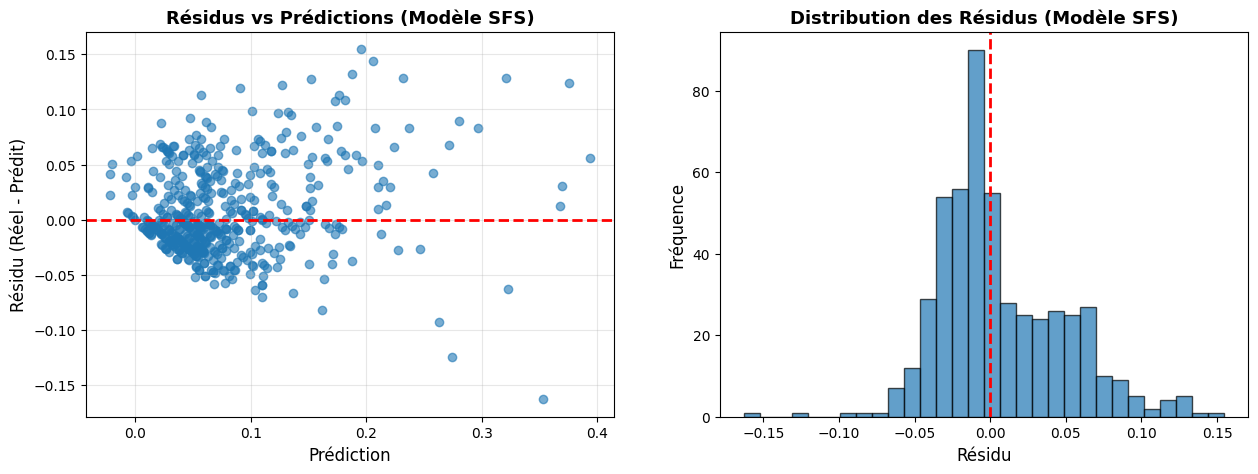

In [16]:
### Residus


# Utilisation des prédictions déjà calculées sur X_test (échelle originale)
# y_test_risk est la vraie cible sur X_test
y_test_risk = y_test['risk'].values
# Nous utilisons la prédiction du modèle SFS (calculée dans le bloc "Application SFS")
# y_pred_final a été mis à jour avec le résultat de la prédiction SFS.
y_pred_test_risk = y_pred_sfs # y_pred_sfs est la prédiction sur X_test_sfs

# Calcul des résidus
residuals = y_test_risk - y_pred_test_risk

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_test_risk, residuals, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Prédiction', fontsize=12)
axes[0].set_ylabel('Résidu (Réel - Prédit)', fontsize=12)
axes[0].set_title('Résidus vs Prédictions (Modèle SFS)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Distribution des résidus
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Résidu', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title('Distribution des Résidus (Modèle SFS)', fontsize=13, fontweight='bold')
plt.show() # Ajout d'un plt.show() pour s'assurer que le graphique est affiché

### Actual vs Predicted plot
**Intérêt:** Compare les vraies valeurs (y_test) aux valeurs prédites (y_pred). Les points doivent se situer le long de la droite d'identité ($y = x$).

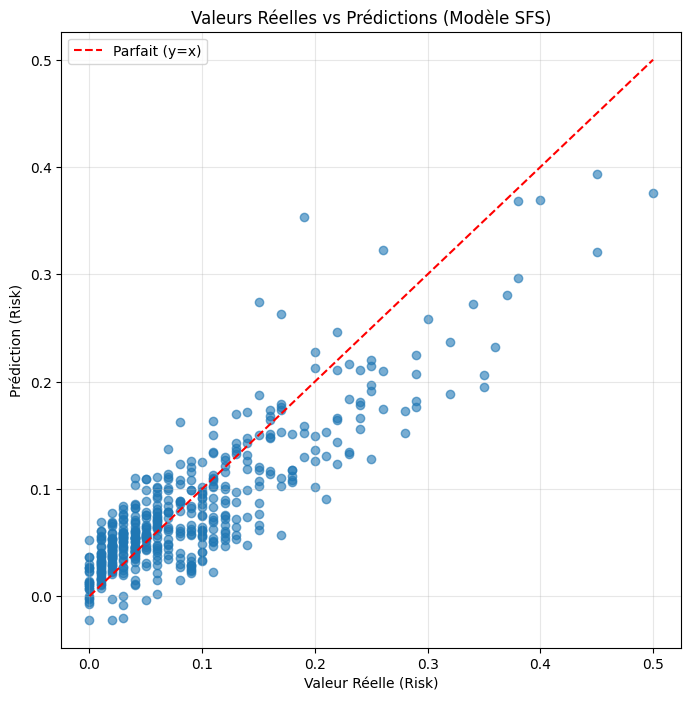

In [17]:
### Actual vs Predicted plot
# Intérêt: Compare les vraies valeurs (y_test) aux valeurs prédites (y_pred).
plt.figure(figsize=(8, 8))
# Utiliser y_pred_sfs (la prédiction du modèle SFS)
plt.scatter(y_test['risk'], y_pred_sfs, alpha=0.6) 
plt.plot([0, y_test['risk'].max()], [0, y_test['risk'].max()], 'r--', label='Parfait (y=x)')
plt.xlabel('Valeur Réelle (Risk)')
plt.ylabel('Prédiction (Risk)')
plt.title('Valeurs Réelles vs Prédictions (Modèle SFS)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Risk on ordinal variables

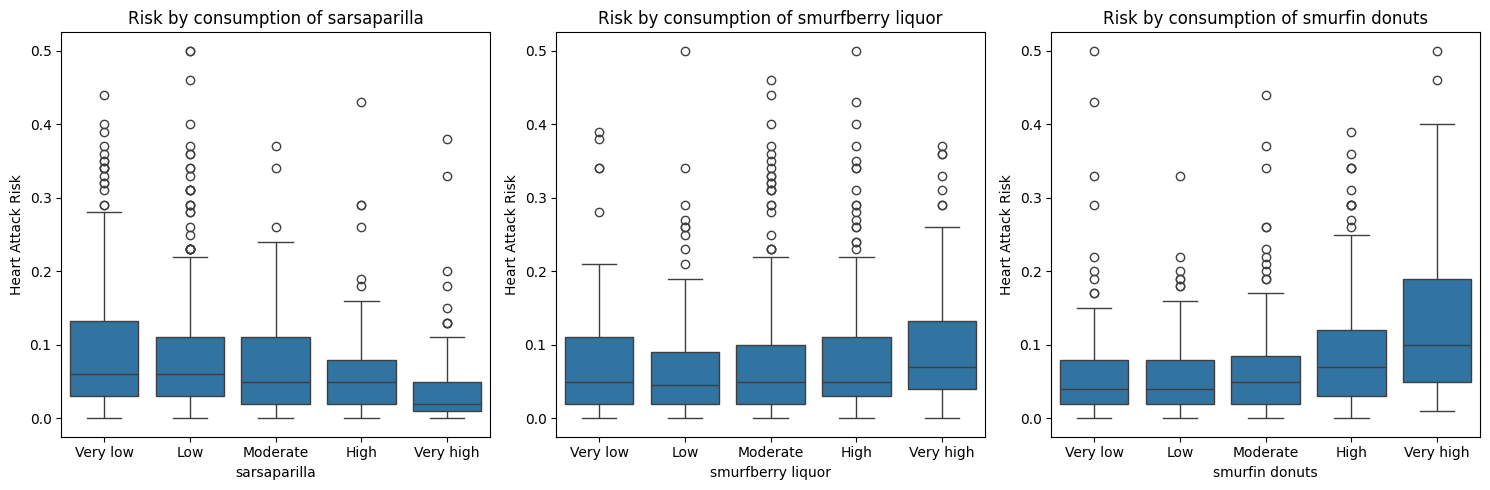

In [18]:
# Variables ordinales (on réutilise data_for_viz pour avoir 'risk')
data_for_viz = X_train.copy()
data_for_viz['risk'] = y_train['risk']

ord_cols = ['sarsaparilla', 'smurfberry liquor', 'smurfin donuts']
ord_categories_ordered = ['Very low', 'Low', 'Moderate', 'High', 'Very high']

plt.figure(figsize=(15, 5))
for i, col in enumerate(ord_cols):
    plt.subplot(1, 3, i + 1)
    # Assure un ordre correct des catégories
    sns.boxplot(x=col, y='risk', data=data_for_viz, order=ord_categories_ordered) 
    plt.title(f'Risk by consumption of {col}')
    plt.xlabel(col)
    plt.ylabel('Heart Attack Risk')
plt.tight_layout()
plt.show()

### ANALYSE DES ERREURS PAR QUANTILE


Faible:
  N samples: 152
  Vraie moyenne: 0.0167
  Prédiction moyenne: 0.0347
  RMSE: 0.0263
  Biais: 0.0180

Moyen:
  N samples: 116
  Vraie moyenne: 0.0487
  Prédiction moyenne: 0.0582
  RMSE: 0.0262
  Biais: 0.0095

Élevé:
  N samples: 123
  Vraie moyenne: 0.0946
  Prédiction moyenne: 0.0748
  RMSE: 0.0390
  Biais: -0.0198

Très Élevé:
  N samples: 109
  Vraie moyenne: 0.2120
  Prédiction moyenne: 0.1713
  RMSE: 0.0677
  Biais: -0.0407


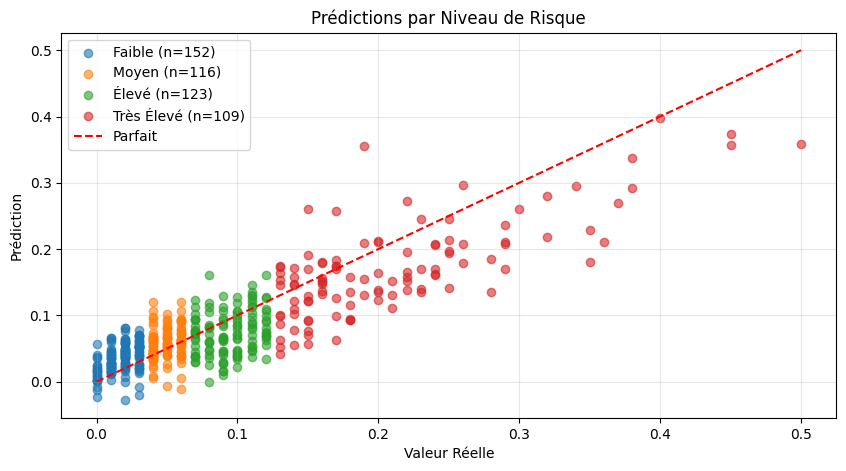

In [19]:
y_test_array = y_test['risk'].values
quantiles = [0, 0.25, 0.5, 0.75, 1.0]
bins = np.quantile(y_test_array, quantiles)
bin_labels = ['Faible', 'Moyen', 'Élevé', 'Très Élevé']

# Assigner chaque échantillon à un bin
y_test_binned = pd.cut(y_test_array, bins=bins, labels=bin_labels, include_lowest=True)

# Calculer RMSE par bin
for label in bin_labels:
    mask = y_test_binned == label
    if mask.sum() > 0:
        rmse_bin = root_mean_squared_error(y_test_array[mask], y_pred_final[mask])
        mean_true = y_test_array[mask].mean()
        mean_pred = y_pred_final[mask].mean()
        print(f"\n{label}:")
        print(f"  N samples: {mask.sum()}")
        print(f"  Vraie moyenne: {mean_true:.4f}")
        print(f"  Prédiction moyenne: {mean_pred:.4f}")
        print(f"  RMSE: {rmse_bin:.4f}")
        print(f"  Biais: {mean_pred - mean_true:.4f}")

# Visualisation
plt.figure(figsize=(10, 5))
for i, label in enumerate(bin_labels):
    mask = y_test_binned == label
    if mask.sum() > 0:
        plt.scatter(y_test_array[mask], y_pred_final[mask], 
                   label=f'{label} (n={mask.sum()})', alpha=0.6)

plt.plot([0, y_test_array.max()], [0, y_test_array.max()], 'r--', label='Parfait')
plt.xlabel('Valeur Réelle')
plt.ylabel('Prédiction')
plt.title('Prédictions par Niveau de Risque')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## RÉSUMÉ FINAL


In [20]:
print(f"Modèle utilisé: {'Ridge Poly + Log(y) + SFS (k=' + str(best_k) + ')' if use_log else 'Ridge Poly + SFS (k=' + str(best_k) + ')'}")
print(f"Meilleurs hyperparamètres (Alpha et Degree): {grid_search.best_params_}") 
print(f"RMSE Cross-Validation (Modèle SFS): {rmse_final_sfs_cv:.4f}")
print(f"RMSE Test Set (Modèle SFS): {rmse_final:.4f}")
print(f"RMSE Baseline (Ridge simple - 18 features): {rmse_baseline:.4f}")
# On compare l'amélioration par rapport au RMSE Baseline (Ridge simple, sans poly, sans log, 18 features)
print(f"Amélioration (par rapport à la Baseline simple): {((rmse_baseline - rmse_final) / rmse_baseline * 100):.2f}%")

Modèle utilisé: Ridge Poly + Log(y) + SFS (k=11)
Meilleurs hyperparamètres (Alpha et Degree): {'poly__degree': 2, 'regressor__regressor__alpha': 200.0}
RMSE Cross-Validation (Modèle SFS): 0.0411
RMSE Test Set (Modèle SFS): 0.0423
RMSE Baseline (Ridge simple - 18 features): 0.0558
Amélioration (par rapport à la Baseline simple): 24.19%


## Sauvegarde du modèle et de y_pred.csv

In [21]:
## Sauvegarde du modèle
os.makedirs('../results/models', exist_ok=True)
model_path = '../results/models/linear_model_ridge_poly.pkl'
joblib.dump(best_model, model_path)
print(f"Modèle sauvegardé: {model_path}")

# Sauvegarder aussi les performances, paramètres, etc.
model_info = {
    'model_name': f'Ridge Polynomial (k={best_k})',
    'model_type': 'linear',
    'use_log_transform': use_log,
    'best_params': grid_search.best_params_,
    'rmse_cv': rmse_final_sfs_cv, # Utilisation du meilleur score SFS
    'rmse_test': rmse_final,      # Utilisation du nouveau RMSE Test
    'rmse_baseline': rmse_baseline,
    'features_count': best_k
}

# Sauvegarder les métadonnées
info_path = '../results/models/linear_model_info.json'
with open(info_path, 'w') as f:
    json.dump(model_info, f, indent=4)
print(f"Metadonnées sauvegardées: {info_path}")
print("\nInformations sauvegardées:")
for key, value in model_info.items():
    if key != 'features_selected_indices':
        print(f"   {key}: {value}")

# Sauvegarde de y_pred.csv
X_unlabeled_processed = preprocessor.transform(X_unlabeled)
X_unlabeled_sfs = X_unlabeled_processed[:, final_best_indices]
predictions = best_model.predict(X_unlabeled_sfs) # best_model est optimal_sfs_model (Poly + TTR/Ridge)
predictions = np.maximum(0, predictions)

print(f"\nStatistiques des prédictions:")
print(f"  Min: {predictions.min():.4f}, Max: {predictions.max():.4f}")
print(f"  Mean: {predictions.mean():.4f}, Std: {predictions.std():.4f}")

final_predictions_df = pd.DataFrame(predictions)
final_predictions_df.to_csv('../results/predictions/y_pred_part1.csv', index=False, header=False)

Modèle sauvegardé: ../results/models/linear_model_ridge_poly.pkl
Metadonnées sauvegardées: ../results/models/linear_model_info.json

Informations sauvegardées:
   model_name: Ridge Polynomial (k=11)
   model_type: linear
   use_log_transform: True
   best_params: {'poly__degree': 2, 'regressor__regressor__alpha': 200.0}
   rmse_cv: 0.04106964336776394
   rmse_test: 0.042314244625975966
   rmse_baseline: 0.05581492537678063
   features_count: 11

Statistiques des prédictions:
  Min: 0.0000, Max: 0.6388
  Mean: 0.0836, Std: 0.0769
